In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.impute import SimpleImputer, KNNImputer
from scipy.stats import zscore

import warnings
warnings.filterwarnings("ignore")

In [85]:
np.random.seed(42)

rows = 5000

df = pd.DataFrame({
    'Age': np.random.randint(18, 70, rows),
    'Income': np.random.normal(50000, 15000, rows),
    'Experience': np.random.randint(0, 40, rows),
    'Spending': np.random.normal(2000, 800, rows),
    'Savings': np.random.normal(15000, 5000, rows)
})

# Add Missing Values
for col in df.columns:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

# Add Outliers
df.loc[np.random.choice(df.index, 30), 'Income'] *= 10
df.loc[np.random.choice(df.index, 30), 'Spending'] *= 8

print(df.shape)
df.head()

(5000, 5)


,Age,Income,Experience,Spending,Savings
0,56.0,48353.457443,31.0,2232.910478,8225.017573
1,69.0,57462.278860,27.0,2606.224115,7719.010760
2,46.0,44219.250087,38.0,2981.215357,14712.361782
3,32.0,56306.787159,39.0,3422.035907,22623.707443
4,60.0,37034.133936,39.0,3177.398576,16105.204270


Age           250
Income        250
Experience    250
Spending      250
Savings       250
dtype: int64


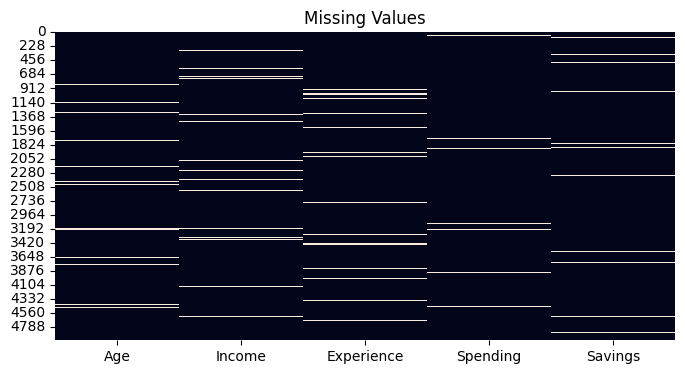

In [86]:
print(df.isnull().sum())

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [87]:
mean_df = df.copy()

mean_imputer = SimpleImputer(strategy='mean')

mean_df[:] = mean_imputer.fit_transform(mean_df)

print("Missing Values After Mean Imputation")
print(mean_df.isnull().sum())

Missing Values After Mean Imputation
Age           0
Income        0
Experience    0
Spending      0
Savings       0
dtype: int64


In [88]:
knn_imputer = KNNImputer(n_neighbors=5)

knn_df = pd.DataFrame(
    knn_imputer.fit_transform(df),
    columns=df.columns
)

print("Missing Values After KNN Imputation")
print(knn_df.isnull().sum())

Missing Values After KNN Imputation
Age           0
Income        0
Experience    0
Spending      0
Savings       0
dtype: int64


In [89]:
z_scores = np.abs(zscore(knn_df))

outliers = (z_scores > 3).sum()

print("Outliers Per Column")
print(outliers)

Outliers Per Column
75


In [90]:
clean_df = knn_df.copy()

for col in clean_df.columns:

    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    clean_df = clean_df[
        (clean_df[col] >= lower) &
        (clean_df[col] <= upper)
    ]

print("Shape Before Cleaning:", knn_df.shape)
print("Shape After Cleaning :", clean_df.shape)

Shape Before Cleaning: (5000, 5)
Shape After Cleaning : (4727, 5)


In [91]:
clean_df['Income_per_YearExperience'] = (
    clean_df['Income'] /
    (clean_df['Experience'] + 1)
)

clean_df['Savings_Ratio'] = (
    clean_df['Savings'] /
    (clean_df['Income'] + 1)
)

clean_df['Spending_to_Income'] = (
    clean_df['Spending'] /
    (clean_df['Income'] + 1)
)

print(clean_df.head())

    Age        Income  Experience     Spending       Savings  \
0  56.0  48353.457443        31.0  2232.910478   8225.017573   
1  69.0  57462.278860        27.0  2606.224115   7719.010760   
2  46.0  44219.250087        38.0  2981.215357  14712.361782   
3  32.0  56306.787159        39.0  3422.035907  22623.707443   
4  60.0  37034.133936        39.0  3177.398576  16105.204270   

   Income_per_YearExperience  Savings_Ratio  Spending_to_Income  
0                1511.045545       0.170098            0.046178  
1                2052.224245       0.134329            0.045355  
2                1133.826925       0.332706            0.067417  
3                1407.669679       0.401786            0.060774  
4                 925.853348       0.434863            0.085794  


In [92]:
clean_df.describe()

,Age,Income,Experience,Spending,Savings,Income_per_YearExperience,Savings_Ratio,Spending_to_Income
count,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000
mean,43.186715,49988.589424,19.022636,1992.279110,14987.141723,5346.017034,0.335397,0.044544
std,14.636382,14611.033626,11.232615,757.349791,4677.254232,8964.640583,0.182588,0.025919
min,18.000000,9301.360488,0.000000,-66.365217,2198.915962,257.308082,0.037602,-0.001338
25%,31.000000,40000.057428,10.000000,1484.453321,11785.950262,1633.625563,0.221640,0.028147
50%,43.000000,50020.694765,18.400000,1988.472673,15120.957478,2553.095419,0.299942,0.040150
75%,55.000000,59809.709189,28.000000,2502.150630,18131.136758,4706.118964,0.404343,0.054971
max,69.000000,91790.749067,39.000000,4072.073742,27799.214088,84815.059941,2.389771,0.365895


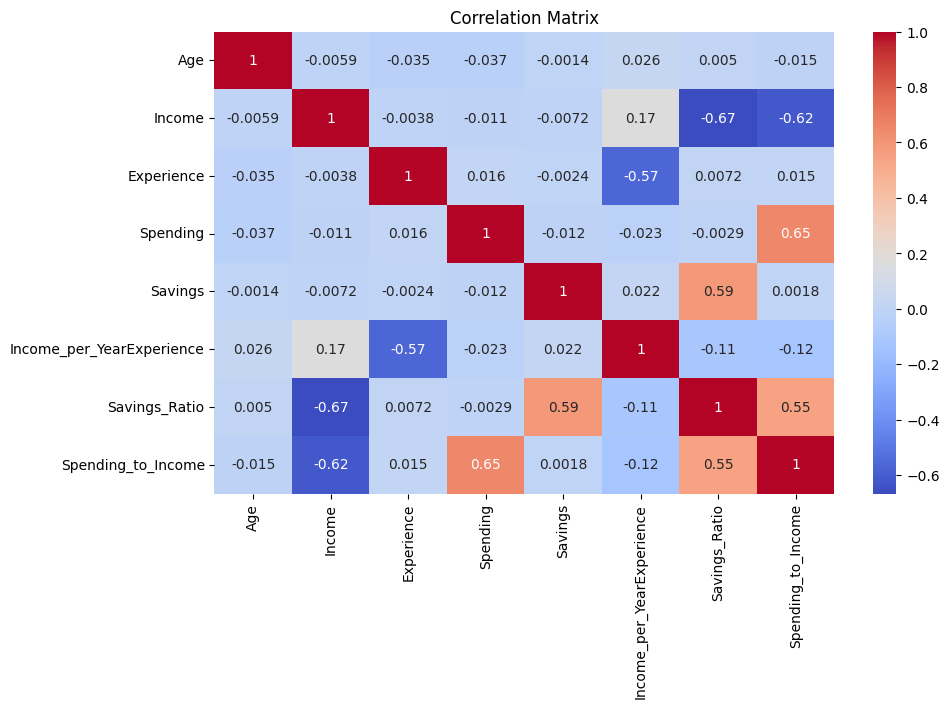

In [93]:
plt.figure(figsize=(10,6))

sns.heatmap(
    clean_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

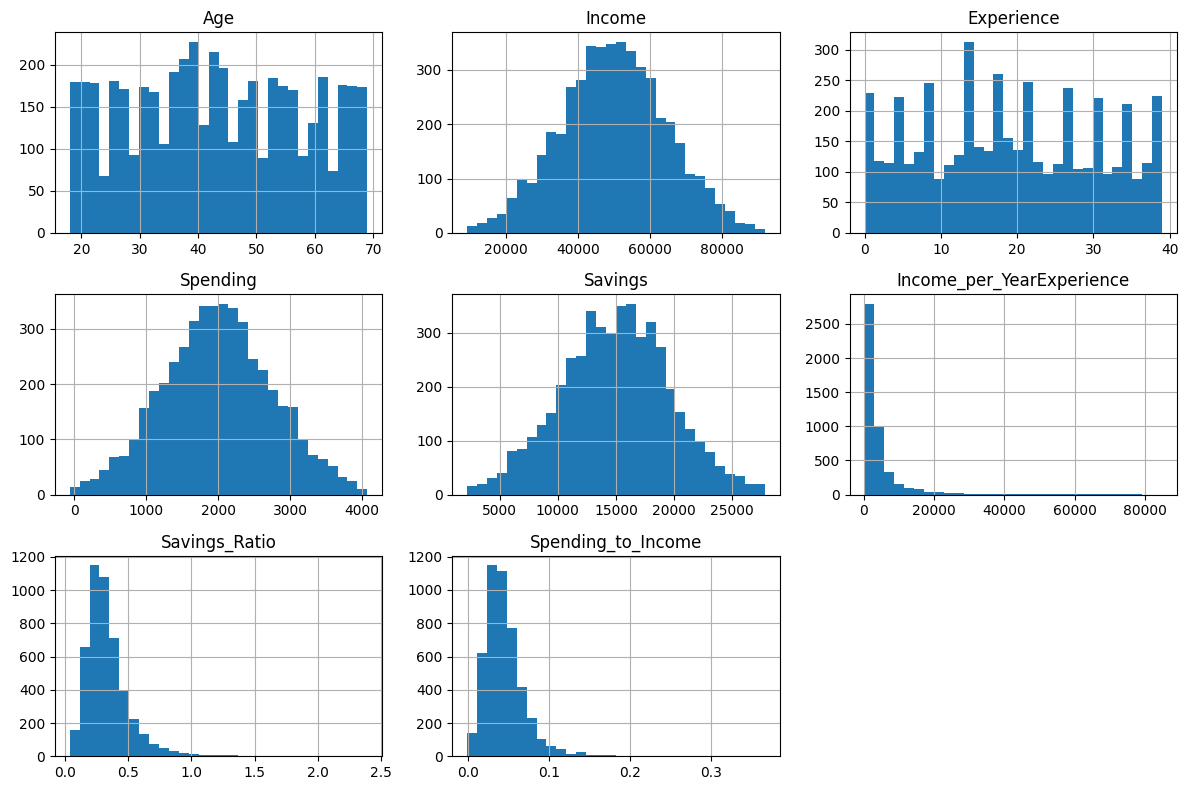

In [94]:
clean_df.hist(
    figsize=(12,8),
    bins=30
)

plt.tight_layout()
plt.show()

In [95]:
clean_df.to_csv(
    "cleaned_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")
print(clean_df.shape)

Dataset Saved Successfully
(4727, 8)
